In [17]:
import os
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np

from pybaselines import Baseline, utils

import lmfit as lm
from lmfit import Model, Parameters, Parameter, report_fit, minimize, Minimizer

from scipy.signal import find_peaks

from assign_peaks import *

In [18]:
def process_files(txt_folder, num_files=999):
    files = [f for f in os.listdir(txt_folder) if not f.startswith('.')]
    files = files[:num_files]  # Vybereme pouze prvních 100 souborů
    df_tim, df_amp = [], []

    for f in files:
        print(f)
        txt_file = os.path.join(txt_folder, f)
        df_tim.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[0]))
        df_amp.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[1]))

    df_all_tim = pd.concat(df_tim, ignore_index=True, axis=1)
    df_all_amp = pd.concat(df_amp, ignore_index=True, axis=1)

    df_all_tim.to_csv('time.csv', sep=',')
    df_all_amp.to_csv('ampl.csv', sep=',')

    df_mean_tim = df_all_tim.mean(axis=1)
    df_mean_tim.to_csv('time_aver.txt', sep=',')
    df_mean_amp = df_all_amp.mean(axis=1)
    df_mean_amp.to_csv('ampl_aver.txt', sep=',')

    with open('averaged.txt', 'w') as f:
        pd.concat([df_mean_tim, df_mean_amp], axis=1).to_csv(f, sep=',')

    print('!Averaging finished!')

# Použití
txt_folder = '2fexp10_2'
process_files(txt_folder)

C2_2025-03-06_PS_K2_10proCO2_00000.txt
C2_2025-03-06_PS_K2_10proCO2_00001.txt
C2_2025-03-06_PS_K2_10proCO2_00002.txt
C2_2025-03-06_PS_K2_10proCO2_00003.txt
C2_2025-03-06_PS_K2_10proCO2_00004.txt
C2_2025-03-06_PS_K2_10proCO2_00005.txt
C2_2025-03-06_PS_K2_10proCO2_00006.txt
C2_2025-03-06_PS_K2_10proCO2_00007.txt
C2_2025-03-06_PS_K2_10proCO2_00008.txt
C2_2025-03-06_PS_K2_10proCO2_00009.txt
C2_2025-03-06_PS_K2_10proCO2_00010.txt
C2_2025-03-06_PS_K2_10proCO2_00011.txt
C2_2025-03-06_PS_K2_10proCO2_00012.txt
C2_2025-03-06_PS_K2_10proCO2_00013.txt
C2_2025-03-06_PS_K2_10proCO2_00014.txt
C2_2025-03-06_PS_K2_10proCO2_00015.txt
C2_2025-03-06_PS_K2_10proCO2_00016.txt
C2_2025-03-06_PS_K2_10proCO2_00017.txt
C2_2025-03-06_PS_K2_10proCO2_00018.txt
C2_2025-03-06_PS_K2_10proCO2_00019.txt
C2_2025-03-06_PS_K2_10proCO2_00020.txt
C2_2025-03-06_PS_K2_10proCO2_00021.txt
C2_2025-03-06_PS_K2_10proCO2_00022.txt
C2_2025-03-06_PS_K2_10proCO2_00023.txt
C2_2025-03-06_PS_K2_10proCO2_00024.txt
C2_2025-03-06_PS_K2_10pro

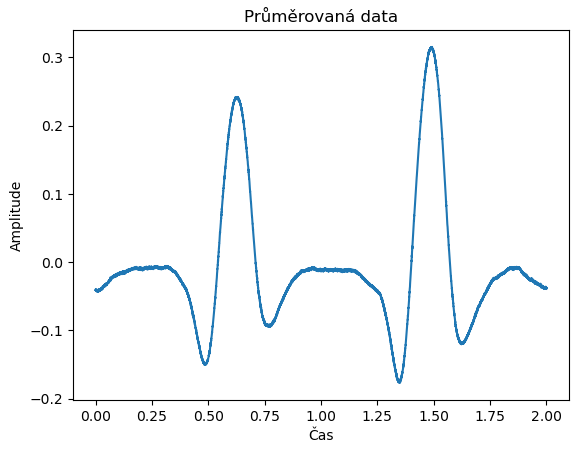

In [19]:
# Načtení průměrovaných dat ze souborů
df_mean_tim = pd.read_csv('time_aver.txt', sep=',', header= None, skiprows=1)
df_mean_amp = pd.read_csv('ampl_aver.txt', sep=',', header= None,  skiprows=1)
# Převod na numpy array
xs = df_mean_tim[1].to_numpy()
ys = df_mean_amp[1].to_numpy()

# Posun hodnot na x-ové ose o 2 sekundy
xs = xs + 2

# Vykreslení grafu
plt.plot(xs, ys)
plt.xlabel('Čas')
plt.ylabel('Amplitude')
plt.title('Průměrovaná data')
plt.show()

InputFile = 'averaged.txt'

In [20]:
#Number_of_Samples_per_Second
print(len(xs))
SpS = int(len(xs)/np.max(xs))
print("!Sampling rate of the datases is " + str(SpS) + " Samples/s!" )

10001
!Sampling rate of the datases is 5000 Samples/s!


In [21]:
Out1 = PdfPages('out2f_exp.pdf')
Out2 = PdfPages('out2f_fit.pdf')

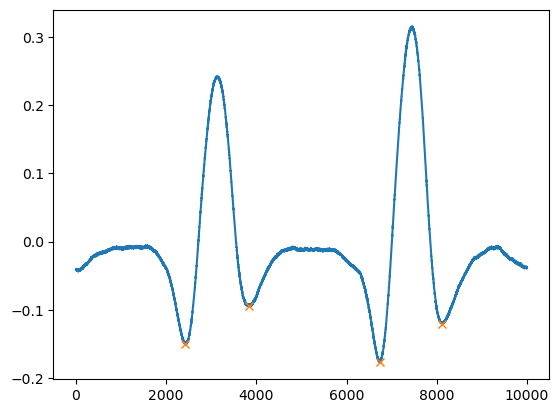

In [22]:
peaks, _ = find_peaks(-ys, height=0.05, distance=500, width=300)
np.diff(peaks)
plt.plot(ys)
plt.plot(peaks, ys[peaks], "x")
plt.show()

xpik = xs[peaks]
ypik = ys[peaks]

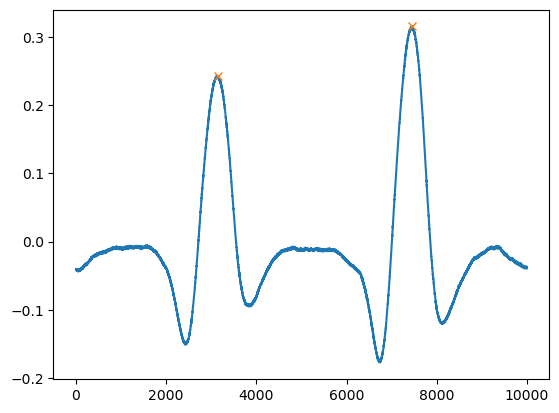

In [23]:

valleys, _ = find_peaks(ys, height=0.1, distance=500, width=250)
np.diff(valleys)
plt.plot(ys)
plt.plot(valleys, ys[valleys], "x")
plt.show()

xval = xs[valleys]
yval = ys[valleys]

In [24]:
#vytvoreni pole objektu peaku
peak_objects = AssignPeaks(xpik, xval, ypik, yval)
numpeak = len(peak_objects)
#overeni delek poli minim a maxim
VerifyPeaksLength(xpik, xval, peak_objects)
#vypsat
SavePeakSpectra(peak_objects, xs, ys, InputFile, 2)

Peaks matched/consistent definition!
Total number of peaks identified in 2f-WMS signal is: 2
Peak1 centered at: 0.6292981876876882(left minimum: 0.48529818768768784; right minimum: 0.7658981876876887)
Peak2 centered at: 1.4924981873273273(left minimum: 1.3478981873273277; right minimum: 1.6222981873273268)


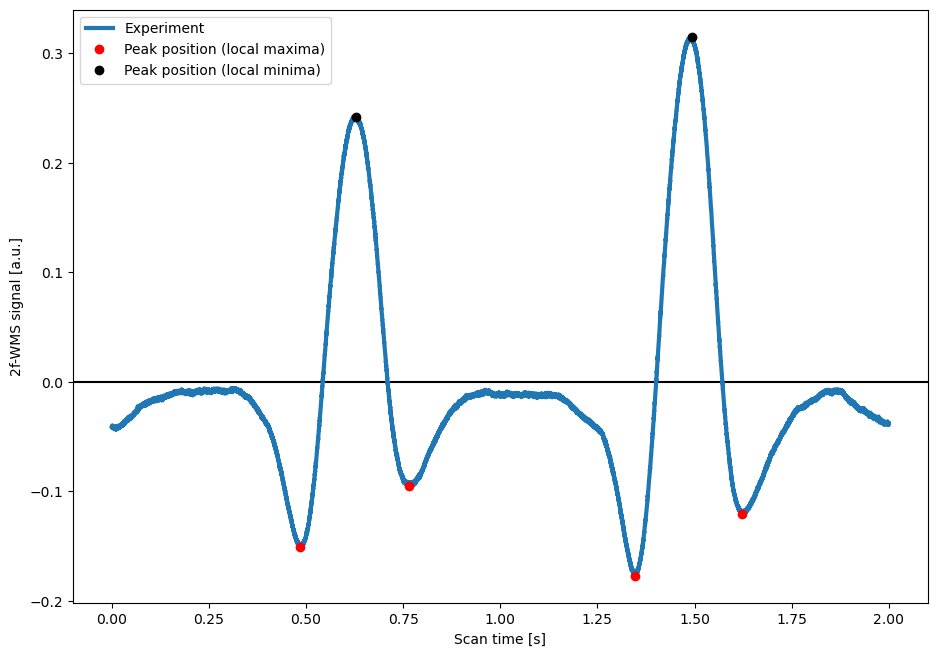

In [25]:
plt.figure(2) 
plt.axhline(0, color='k') 
line1, = plt.plot(xs, ys, linewidth=3, label='Experiment') 
point1, = plt.plot(xpik, ypik, 'ro', linewidth=5, label='Peak position (local maxima)') 
point2, = plt.plot(xval, yval, 'ko', linewidth=5, label='Peak position (local minima)') 
plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)}) 
plt.xlabel(r"Scan time [s]") 
plt.ylabel(r"2f-WMS signal [a.u.]") 
plt.tight_layout() 
a4 = plt.gcf() 
a4.set_size_inches([10,7]) 
a4.savefig(Out1, format='pdf') 
plt.show() 
Out1.close()

In [26]:
def lorentzianA(xs, a0, a1, a2):
    return a0/(np.pi*a2*(1+((xs-a1)/a2)**2))

def D2lorentzianA(xs, a0, a1, a2):
    return -2*a0*a2*(a2**2-3*(a1-xs)**2)/(np.pi*(a2**2+(a1-xs)**2)**3)

def gaussianA(xs, a0, a1, a2):
    sigma = a2/np.sqrt(2*np.log(2))
    return a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(xs-a1)**2/(2*sigma**2))

def D2gaussianA(xs, a0, a1, a2):
    sigma = np.sqrt(2*np.log(2))*a2
    poly2 = ((xs-a1)**2-sigma**2)/sigma**4
    return poly2*a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(xs-a1)**2/(2*sigma**2))

In [27]:
result=[None]*numpeak
par=[None]*numpeak
resdata=[None]*numpeak
ofst=[None]*numpeak
minner=[None]*numpeak
res2ult=[None]*numpeak
fin2ual=[None]*numpeak
res2data=[None]*numpeak
par2am=[None]*numpeak
gabor2=[None]*numpeak
gabor4=[None]*numpeak
gabor6=[None]*numpeak
gabor8=[None]*numpeak
gabor10=[None]*numpeak

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 2434
    # data points      = 4305
    # variables        = 3
    chi-square         = 2.44221966
    reduced chi-square = 5.6769e-04
    Akaike info crit   = -32172.2610
    Bayesian info crit = -32153.1584
    R-squared          = 0.93257347
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    a0: -0.00128747 (init = 0.2420568)
    a1:  0.62666525 (init = 0.1962982)
    a2:  0.14231144 (init = 0.17216)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 260
    # data points      = 4305
    # variables        = 14
    chi-square         = 0.04040898
    reduced chi-square = 9.4171e-06
    Akaike info crit   = -49807.6950
    Bayes

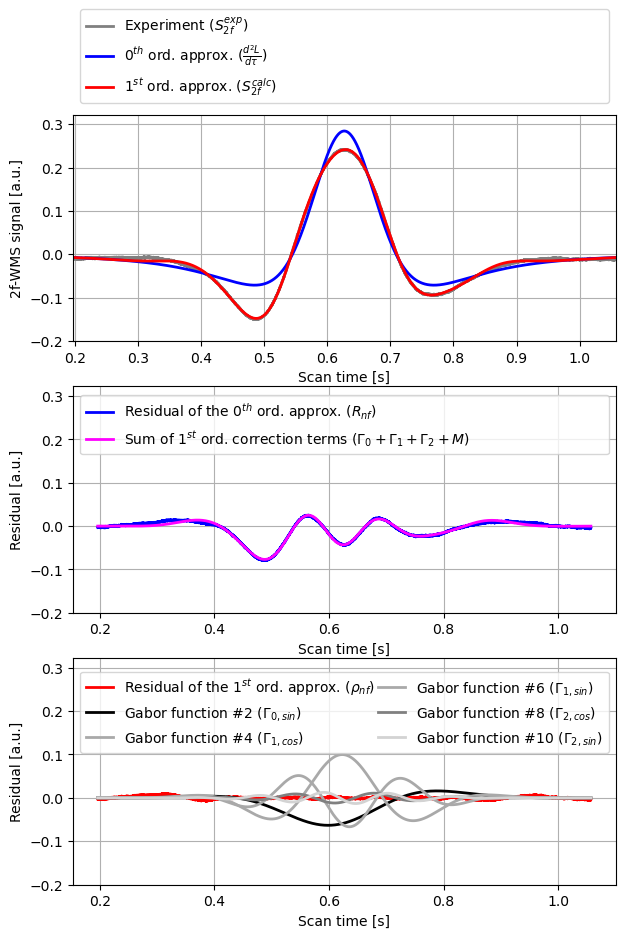

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1961
    # data points      = 4273
    # variables        = 3
    chi-square         = 2.73541517
    reduced chi-square = 6.4061e-04
    Akaike info crit   = -31416.7370
    Bayesian info crit = -31397.6568
    R-squared          = 0.95317330
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    a0: -0.00173724 (init = 0.3153432)
    a1:  1.48736117 (init = 1.058898)
    a2:  0.14520575 (init = 0.17088)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 213
    # data points      = 4273
    # variables        = 14
    chi-square         = 0.05293627
    reduced chi-square = 1.2429e-05
    Akaike info crit   = -48251.5071
    Bayesi

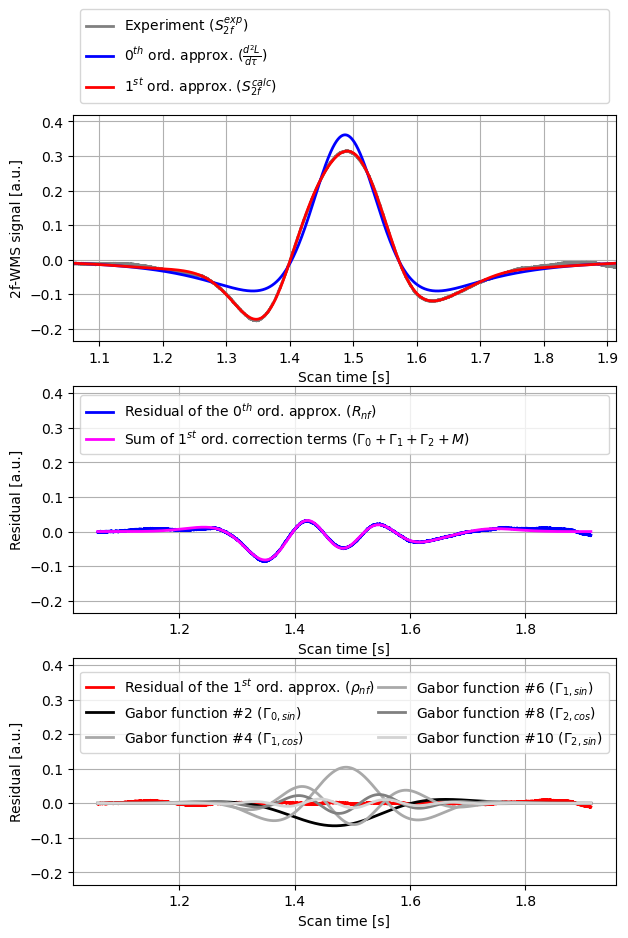

In [28]:
for i in range(1,numpeak+1):
    j=i-1
    
    InputFilePeaks = InputFile.replace(".txt", '_Peak') + str(i) + '.txt'
    Dataset = np.loadtxt(InputFilePeaks, skiprows= 0 + 1 + 2 + 3 + 4 , delimiter=',')
    x = Dataset[:, 0]
    y = Dataset[:, 1]

    Out3i = PdfPages('out_peakfit' + str(i) + '.pdf')
    
    params = lm.Parameters()
    params.add('a0', value=np.maximum(np.abs(np.amax(-y)),np.abs(np.amin(-y))), min=10*np.amin(-y), max=10*np.amax(-y))
    params.add('a1', value=np.amin(x)-(np.amax(x)-np.amin(x))/2, min=np.amin(x), max=np.amax(x))
    params.add('a2', value=(np.amax(x)-np.amin(x))/5, min=(np.amax(x)-np.amin(x))/10, max=(np.amax(x)-np.amin(x))/2)

    #model = lm.Model(D2gaussianA)
    model = lm.Model(D2lorentzianA)
     #result[j] = model.fit(y, params, x=x, method='leastsq')
    result[j] = model.fit(y, params, xs=x, method='differential_evolution')
    
    lm.report_fit(result[j])

    par[j] = result[j].best_values
   
    resdata[j] = result[j].residual
    
    #ofst[j] = np.mean(resdata[j])
    ofst[j] = 0
    
    def residual(params, x, resdata):
        "Gabor polynomial"
        params['a0']= Parameter(name = 'a0', value = par[j]['a0'] , vary = False)
        params['a1']= Parameter(name = 'a1', value = par[j]['a1'] , vary = False)
        params['a2']= Parameter(name = 'a2', value = par[j]['a2'] , vary = False)

        off = params['off']
        params['off']= Parameter(name = 'off', value = ofst[j] , vary = False)
        k2 = params['k2']
        k4 = params['k4']
        k6 = params['k6']

        k8 = params['k8']
        fi8 = params['fi8']
        
        k10 = params['k10']
        fi10 = params['fi10']

        fi6 = params['fi6']
        fi4 = params['fi4']
        fi2 = params['fi2']
        
        a0 = params['a0']
        a1 = params['a1']
        a2 = params['a2']

        w = params['w']

        sigma = a2/np.sqrt(2*np.log(2))
        gabor10 = np.cos(2*np.pi*(5/2)*(x-a1)/(2*a2)+fi10)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor8 = np.cos(2*np.pi*(4/2)*(x-a1)/(2*a2)+fi8)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor6 = np.sin(2*np.pi*(3/2)*(x-a1)/(2*a2)+fi6)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor4 = np.cos(2*np.pi*(2/2)*(x-a1)/(2*a2)+fi4)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor2 = np.sin(2*np.pi*(1/2)*(x-a1)/(2*a2)+fi2)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        
        return off + k10*gabor10 + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        #return off + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        #return off + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
    
        # create a set of Parameters
    
    params.add('off', min=-par[j]['a0'], max=par[j]['a0'], vary = False)
    params.add('k6', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k4', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k2', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k8', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k10', value=1.0, min=-50, max=50.0, vary = True)
    params.add('fi10', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi8', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi6', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi4', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi2', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('w', value=1.33, min= 1/3, max=5/3, vary = True)

       
    # do fit, here with leastsq model
    minner[j] = Minimizer(residual, params, fcn_args=(x, resdata[j]))
    res2ult[j] = minner[j].minimize(method = 'leastsq')
    # res2ult[j] = minner[j].minimize(method = 'differential_evolution')

    par2am[j] = res2ult[j].params
    #par2am[j].pretty_print()

    offj=par2am[j]['off'].value
    a0j=par2am[j]['a0'].value
    a1j=par2am[j]['a1'].value
    a2j=par2am[j]['a2'].value
    k6j=par2am[j]['k6'].value
    k4j=par2am[j]['k4'].value
    k2j=par2am[j]['k2'].value
    k8j=par2am[j]['k8'].value
    k10j=par2am[j]['k10'].value
    fi10j=par2am[j]['fi10'].value
    fi8j=par2am[j]['fi8'].value
    fi6j=par2am[j]['fi6'].value
    fi4j=par2am[j]['fi4'].value
    fi2j=par2am[j]['fi2'].value
    sigmaj = a2j/np.sqrt(2*np.log(2))
    wj=par2am[j]['w'].value

    gabor10[j] = np.sin(5*np.pi*(x-a1j)/(2*a2j)+fi10j)*k10j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor8[j] = np.cos(4*np.pi*(x-a1j)/(2*a2j)+fi8j)*k8j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor6[j] = np.sin(3*np.pi*(x-a1j)/(2*a2j)+fi6j)*k6j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor4[j] = np.cos(2*np.pi*(x-a1j)/(2*a2j)+fi4j)*k4j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor2[j] = np.sin(1*np.pi*(x-a1j)/(2*a2j)+fi2j)*k2j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))

    res2data[j] = res2ult[j].residual
    
    # calculate final result
    fin2ual[j] = resdata[j] + res2data[j]
    
    # write error report
    report_fit(res2ult[j])
    
    # write signal curve after Gabor fitting into csv file{x, result[j].best_fit-fin2ual[j]}
    # Create a DataFrame directly for each index j
    df = pd.DataFrame({'x': x, 'y': result[j].best_fit + fin2ual[j] + offj})
    # Write DataFrame to CSV file, naming it based on index j
    goutput_filename = f'goutput_{j+1}.csv'
    df.to_csv(goutput_filename, index=False)
    print(f'Data written to {goutput_filename} successfully.')
    
    fig2 = plt.figure(2)
    
    ax1=plt.subplot(311)
    line2, = plt.plot(x, y, 'grey', linewidth=2, label= r'Experiment ($S_{2f}^{exp}$)')
    line3, = plt.plot(x, result[j].best_fit, 'blue', linewidth=2, label= r'$0^{th}$ ord. approx. ($\frac{d^{2}L}{d\tau}$)')
    line3f, = plt.plot(x, result[j].best_fit+fin2ual[j], 'red', linewidth=2, label= r'$1^{st}$ ord. approx. ($S_{2f}^{calc}$)')
    plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=1)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"2f-WMS signal [a.u.]")
    plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 1.33*np.amin(y), 1.33*np.amax(y),])
    plt.grid(True)

    ax2=plt.subplot(312, sharey=ax1)
    line4, = plt.plot(x, result[j].residual, 'blue',linewidth=2, label=r'Residual of the $0^{th}$ ord. approx. ($R_{nf}$)')
    line5, = plt.plot(x, fin2ual[j], 'magenta', linewidth=2, label=r'Sum of $1^{st}$ ord. correction terms ($\Gamma_0 + \Gamma_1 + \Gamma_2 + M$)')
    plt.legend(handler_map={line4: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,0.67,1,0.2), loc="lower left", mode="expand", ncol=1)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), -1.5*np.amax(result[j].residual), -2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    ax3=plt.subplot(313, sharey=ax1)
    line6, = plt.plot(x, -res2ult[j].residual, 'red',linewidth=2, label=r'Residual of the $1^{st}$ ord. approx. ($\rho_{nf}$)')
    line7, = plt.plot(x, gabor2[j], 'black',linewidth=2, label= r'Gabor function #2 ($\Gamma_{0,sin}$)')
    line8, = plt.plot(x, gabor4[j], 'darkgray',linewidth=2, label= r'Gabor function #4 ($\Gamma_{1,cos}$)')
    line9, = plt.plot(x, gabor6[j], 'darkgrey',linewidth=2, label=r'Gabor function #6 ($\Gamma_{1,sin}$)')
    line10, = plt.plot(x, gabor8[j], 'grey',linewidth=2, label=r'Gabor function #8 ($\Gamma_{2,cos}$)')
    line11, = plt.plot(x, gabor10[j], 'lightgrey',linewidth=2, label=r'Gabor function #10 ($\Gamma_{2,sin}$)')
    #line11, = plt.plot(x, -gabor2[j]-gabor4[j]-gabor6[j]-gabor8[j], 'm:',linewidth=4)
    plt.legend(handler_map={line6: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,0.55,1,0.2), loc="lower left", mode="expand", ncol=2)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 2.0*offj-1.5*np.amax(result[j].residual), 2.0*offj-2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    #plt.tight_layout()
    a4 = plt.gcf()
    a4.set_size_inches([7,10])
    a4.savefig(Out2, format='pdf')
    a4.savefig(Out3i, format='pdf')
    plt.show()

    Out3i.close()
    
Out2.close()

In [190]:
# g1_x, g1_y for peak g1 around 37
OutputFile1 = 'goutput_1.csv'
Dataset1 = np.loadtxt(OutputFile1, skiprows=1, delimiter=',')
g1_x = Dataset1[:, 0]
g1_y = Dataset1[:, 1]

# g2_x, g2_y for the second peak (you can specify the correct file or arrays)
OutputFile2 = 'goutput_2.csv'
Dataset2 = np.loadtxt(OutputFile2, skiprows=1, delimiter=',')
g2_x = Dataset2[:, 0]
g2_y = Dataset2[:, 1]

# Create new y array with zeros outside the range of the two peaks
goutput_y = np.zeros_like(xs)

# Set y-values for the first peak
goutput_y[(xs >= np.min(g1_x)) & (xs <= np.max(g1_x))] = g1_y[(g1_x >= np.min(g1_x)) & (g1_x <= np.max(g1_x))]

# Set y-values for the second peak
goutput_y[(xs >= np.min(g2_x)) & (xs <= np.max(g2_x))] = g2_y[(g2_x >= np.min(g2_x)) & (g2_x <= np.max(g2_x))]

# Save the new array to a CSV file if needed
goutput = np.column_stack((xs, goutput_y))
np.savetxt('goutput.csv', goutput, delimiter=',', header='x,y', comments='')

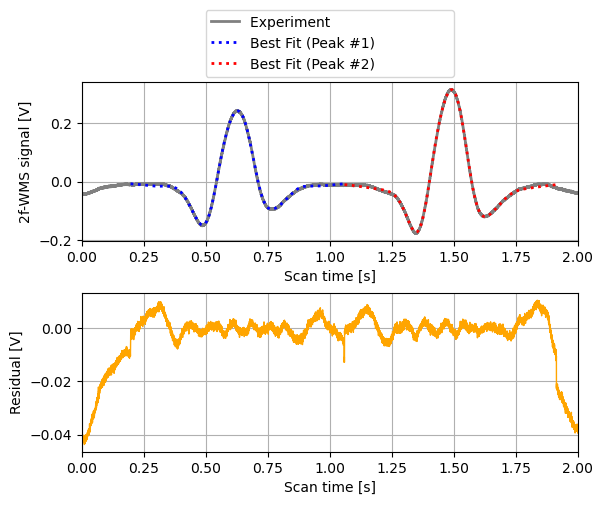

Peak 1:
  - Height of peak (h2f): 0.2420567569569574
  - Amplitude of peak (a2f): 0.3648308126626623
Peak 2:
  - Height of peak (h2f): 0.3153432026026034
  - Amplitude of peak (a2f): 0.4641102638638638


In [191]:
fig4 = plt.figure(2)

ax1 = plt.subplot(211)
plt.plot(xs, ys, 'grey', linewidth=2,  label='Experiment                           ')
plt.plot(g1_x, g1_y, 'blue', linestyle="dotted", linewidth=2, label='Best Fit (Peak #1)')
plt.plot(g2_x, g2_y, 'red', linestyle="dotted", linewidth=2, label='Best Fit (Peak #2)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.5), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("2f-WMS signal [V]")
plt.xlim([0, 2])
plt.grid(True)

ax2 = plt.subplot(212)
plt.plot(xs, ys-goutput_y, 'orange', linewidth=1)
#plt.plot(xs, ys-goutput_y, 'blue', linewidth=2, label='Residual (Experiment (w/o background subtraction) - Best Fit)')
#ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.33), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("Residual [V]")
plt.xlim([0, 2])
plt.grid(True)

# Adjust vertical space between subplots
fig4.subplots_adjust(hspace=0.33)

plt.show()

h2f_values = []  # Výšky od nuly
a2f_values = []  # Amplitudy

# Pro každý peak v poli peak_objects
for peak in peak_objects:
    h2f = peak.s2_max  # Výška od nuly
    a2f = peak.s2_ampl  # Amplituda

    h2f_values.append(h2f)
    a2f_values.append(a2f)

# Výpis výsledků
for i, (h2f, a2f) in enumerate(zip(h2f_values, a2f_values)):
    print(f"Peak {i+1}:")
    print(f"  - Height of peak (h2f): {h2f}")
    print(f"  - Amplitude of peak (a2f): {a2f}")

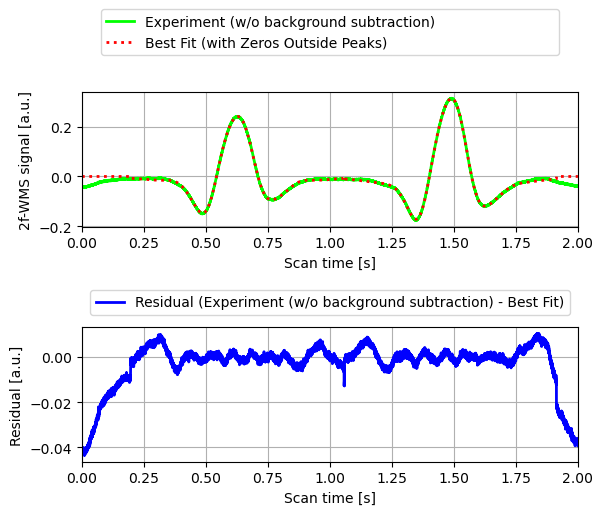

In [31]:
import matplotlib.pyplot as plt

fig3 = plt.figure(2)

ax1 = plt.subplot(211)
#plt.plot(xs, ys+bkg, 'grey', linewidth=2, label='Experiment ($S_{2f}^{exp}$)')
plt.plot(xs, ys, 'lime', linewidth=2,  label='Experiment (w/o background subtraction)                           ')
plt.plot(xs, goutput_y, 'red', linestyle="dotted", linewidth=2, label='Best Fit (with Zeros Outside Peaks)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.67), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("2f-WMS signal [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

ax2 = plt.subplot(212)
plt.plot(xs, ys-goutput_y, 'blue', linewidth=2, label='Residual (Experiment (w/o background subtraction) - Best Fit)')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.33), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("Residual [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

# Adjust vertical space between subplots
fig3.subplots_adjust(hspace=0.75)

plt.show()

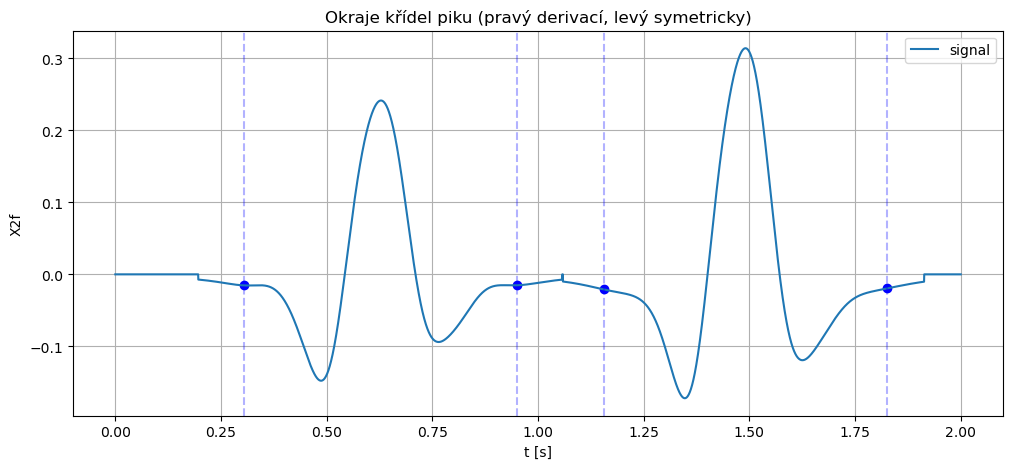

In [186]:
from scipy.signal import find_peaks

def find_outer_wing_edge_symmetric(x, y, peak_idxs, window=2000, prominence=0.001):
    """
    Najde okraj křídla piku:
    - na PRAVÉ straně pomocí maxima d2y (find_peaks),
    - na LEVÉ straně symetricky podle vzdálenosti od maxima piku.
    """
    wing_edges = []

    for p in peak_idxs:

        x_peak = x[p]

        # lokální okno kolem piku
        i1 = max(0, p - window)
        i2 = min(len(x), p + window)

        x_loc = x[i1:i2]
        y_loc = y[i1:i2]

        # derivace
        dy = np.gradient(y_loc, x_loc)
        d2y = np.gradient(dy, x_loc)

        # PRAVÉ křídlo
        right_mask = x_loc > x_peak
        x_right = x_loc[right_mask]
        y_right = y_loc[right_mask]
        d2y_right = d2y[right_mask]

        # najdeme lokální maxima d2y na pravém křídle
        if len(d2y_right) > 3:
            peaks_right, _ = find_peaks(d2y_right, prominence=prominence)
            if len(peaks_right) > 0:
                idxR = peaks_right[-1]          # poslední maximum = okraj křídla
            else:
                idxR = np.argmax(d2y_right)     # fallback: globální maximum
        else:
            idxR = np.argmax(d2y_right)

        right_x = x_right[idxR]
        right_y = y_right[idxR]

        # SYMETRICKÝ LEVÝ BOD
        # vzdálenost od maxima piku
        dx = right_x - x_peak
        left_x_target = x_peak - dx

        # najdeme nejbližší x vlevo od piku
        left_mask = x_loc < x_peak
        x_left = x_loc[left_mask]
        y_left = y_loc[left_mask]

        if len(x_left) > 0:
            idxL = np.argmin(np.abs(x_left - left_x_target))
            left_x = x_left[idxL]
            left_y = y_left[idxL]
        else:
            # fallback: úplně levý bod v okně
            left_x = x_loc[0]
            left_y = y_loc[0]

        wing_edges.append((left_x, left_y))
        wing_edges.append((right_x, right_y))

    return wing_edges

wing_edges = find_outer_wing_edge_symmetric(x, y, peak_idxs, window=2000, prominence=0.001)

plt.figure(figsize=(12,5))
plt.plot(x, y, label="signal")

for xi, yi in wing_edges:
    plt.scatter(xi, yi, color="blue")
    plt.axvline(xi, color="blue", linestyle="--", alpha=0.3)

plt.title("Okraje křídel piku (pravý derivací, levý symetricky)")
plt.xlabel("t [s]")
plt.ylabel("X2f")
plt.grid(True)
plt.legend()
plt.show()



Peak 1 inflex (blue): (np.float64(0.3056981876876881), np.float64(-0.015400055808838492)) (np.float64(0.9512981876876867), np.float64(-0.015193091836562636))
Peak 2 inflex (blue): (np.float64(1.155898187327327), np.float64(-0.02100048436504879)) (np.float64(1.8258981873273277), np.float64(-0.01953102213593529))
Baseline peak 1: y = 0.000321 * x + -0.015498
Baseline peak 2: y = 0.002193 * x + -0.023536


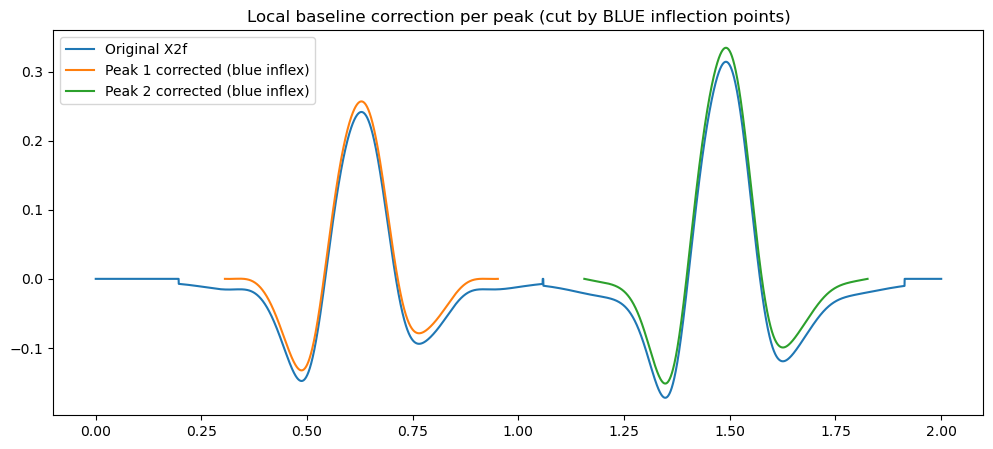

In [187]:
# ------------------------------------------------------------
# 4) Robustní baseline korekce podle MODRÝCH inflexních bodů (wing_edges)
# ------------------------------------------------------------

# Seřadíme modré body podle x
inflex_sorted = sorted(wing_edges, key=lambda p: p[0])

# Pozice maxim obou peaků
p1_max = x[peak_idxs[0]]
p2_max = x[peak_idxs[1]]

# Funkce: najde levý a pravý inflexní bod k peaku z modrých bodů
def robust_inflex_for_peak(peak_x, inflex_sorted):
    left_candidates  = [pt for pt in inflex_sorted if pt[0] < peak_x]
    right_candidates = [pt for pt in inflex_sorted if pt[0] > peak_x]

    # fallbacky pro chybějící body
    if len(left_candidates) == 0 and len(right_candidates) == 0:
        return (peak_x - 0.5, 0), (peak_x + 0.5, 0)

    if len(left_candidates) == 0:
        right_pt = right_candidates[0]
        left_pt = (peak_x - abs(right_pt[0] - peak_x), right_pt[1])
        return left_pt, right_pt

    if len(right_candidates) == 0:
        left_pt = left_candidates[-1]
        right_pt = (peak_x + abs(left_pt[0] - peak_x), left_pt[1])
        return left_pt, right_pt

    # normální případ
    left_pt  = left_candidates[-1]
    right_pt = right_candidates[0]
    return left_pt, right_pt

# přiřazení modrých inflexních bodů k peakům
p1_left_pt, p1_right_pt = robust_inflex_for_peak(p1_max, inflex_sorted)
p2_left_pt, p2_right_pt = robust_inflex_for_peak(p2_max, inflex_sorted)

print("Peak 1 inflex (blue):", p1_left_pt, p1_right_pt)
print("Peak 2 inflex (blue):", p2_left_pt, p2_right_pt)

# rozbalení bodů
x1L, y1L = p1_left_pt
x1R, y1R = p1_right_pt

x2L, y2L = p2_left_pt
x2R, y2R = p2_right_pt

# ------------------------------------------------------------
# OŘEZÁNÍ PEAKŮ PODLE MODRÝCH INFLEXNÍCH BODŮ
# ------------------------------------------------------------

# Peak 1 interval
mask1 = (x >= x1L) & (x <= x1R)
x1 = x[mask1]
y1 = y[mask1]

# Peak 2 interval
mask2 = (x >= x2L) & (x <= x2R)
x2 = x[mask2]
y2 = y[mask2]

# ------------------------------------------------------------
# Lineární baseline fit pro každý peak (už jen v ořezaném intervalu)
# ------------------------------------------------------------

# Peak 1 baseline
a1 = (y1R - y1L) / (x1R - x1L)
b1 = y1L - a1 * x1L

# Peak 2 baseline
a2 = (y2R - y2L) / (x2R - x2L)
b2 = y2L - a2 * x2L

print("Baseline peak 1: y = {:.6f} * x + {:.6f}".format(a1, b1))
print("Baseline peak 2: y = {:.6f} * x + {:.6f}".format(a2, b2))

# ------------------------------------------------------------
# Odečtení baseline – nyní přesně v ořezaném intervalu
# ------------------------------------------------------------

y_zeroed = np.zeros_like(y)
y_zeroed[mask1] = y1 - (a1 * x1 + b1)
y_zeroed[mask2] = y2 - (a2 * x2 + b2)

plt.figure(figsize=(12,5))
plt.plot(x, y, label="Original X2f")
plt.plot(x1, y_zeroed[mask1], label="Peak 1 corrected (blue inflex)")
plt.plot(x2, y_zeroed[mask2], label="Peak 2 corrected (blue inflex)")
plt.legend()
plt.title("Local baseline correction per peak (cut by BLUE inflection points)")
plt.show()


In [188]:
# ------------------------------------------------------------
# Uložení nulovaného spektra
# ------------------------------------------------------------

df_zeroed = pd.DataFrame({"x": x, "y_zeroed": y_zeroed})
df_zeroed.to_csv("gzeroed.csv", index=False)
print("Korektovaná časová řada uložena do gzeroed.csv")

# ------------------------------------------------------------
# 5) Parametry peaků + FWZC
# ------------------------------------------------------------

peak_data = []

for pid in range(2):
    max_idx = peak_idxs[pid]
    x_max = x[max_idx]
    y_max = y_zeroed[max_idx]

    # inflexní body
    if pid == 0:
        x_inf_left, y_inf_left = x1L, y1L
        x_inf_right, y_inf_right = x1R, y1R
    else:
        x_inf_left, y_inf_left = x2L, y2L
        x_inf_right, y_inf_right = x2R, y2R

    # minima mezi inflexními body
    peak_mask = (x >= x_inf_left) & (x <= x_inf_right)
    xc = x[peak_mask]
    yc = y_zeroed[peak_mask]

    mid_x = x_max
    left_part = xc < mid_x
    right_part = xc > mid_x

    x_min_left = xc[left_part][np.argmin(yc[left_part])] if np.any(left_part) else np.nan
    y_min_left = yc[left_part][np.argmin(yc[left_part])] if np.any(left_part) else np.nan

    x_min_right = xc[right_part][np.argmin(yc[right_part])] if np.any(right_part) else np.nan
    y_min_right = yc[right_part][np.argmin(yc[right_part])] if np.any(right_part) else np.nan

    S2f_min = np.nanmin([y_min_left, y_min_right])
    A2f_corr = y_max - S2f_min
    H2f_corr = y_max

    # Zero-crossings
    def find_zc(xc, yc):
        for i in range(len(xc)-1):
            if yc[i] * yc[i+1] < 0:
                x1, x2 = xc[i], xc[i+1]
                y1, y2 = yc[i], yc[i+1]
                return x1 - y1 * (x2 - x1) / (y2 - y1)
        return np.nan

    zc_left = find_zc(x[(x >= x_min_left) & (x <= x_max)],
                      y_zeroed[(x >= x_min_left) & (x <= x_max)])

    zc_right = find_zc(x[(x >= x_max) & (x <= x_min_right)],
                       y_zeroed[(x >= x_max) & (x <= x_min_right)])

    FWZC = zc_right - zc_left if (not np.isnan(zc_left) and not np.isnan(zc_right)) else np.nan

    peak_data.append([
        pid + 1,
        x_min_left, x_min_right,
        x_max,
        x_inf_left, x_inf_right,
        A2f_corr, H2f_corr,
        zc_left, zc_right,
        FWZC
    ])

# tabulka
cols = [
    "PeakID",
    "x_min_left", "x_min_right",
    "x_max",
    "x_inf_left", "x_inf_right",
    "A2f_corr", "H2f_corr",
    "x_zc_left", "x_zc_right",
    "FWZC"
]
df = pd.DataFrame(peak_data, columns=cols)
print(df)

df.to_csv("peak_parameters_FWZC.csv", index=False)
print("Parametry peaků uloženy do peak_parameters_FWZC.csv")


Korektovaná časová řada uložena do gzeroed.csv
   PeakID  x_min_left  x_min_right     x_max  x_inf_left  x_inf_right  \
0       1    0.486898     0.764898  0.628498    0.305698     0.951298   
1       2    1.347298     1.625698  1.490898    1.155898     1.825898   

   A2f_corr  H2f_corr  x_zc_left  x_zc_right      FWZC  
0  0.389296  0.256820   0.539552    0.714497  0.174945  
1  0.485970  0.334432   1.397442    1.575918  0.178476  
Parametry peaků uloženy do peak_parameters_FWZC.csv


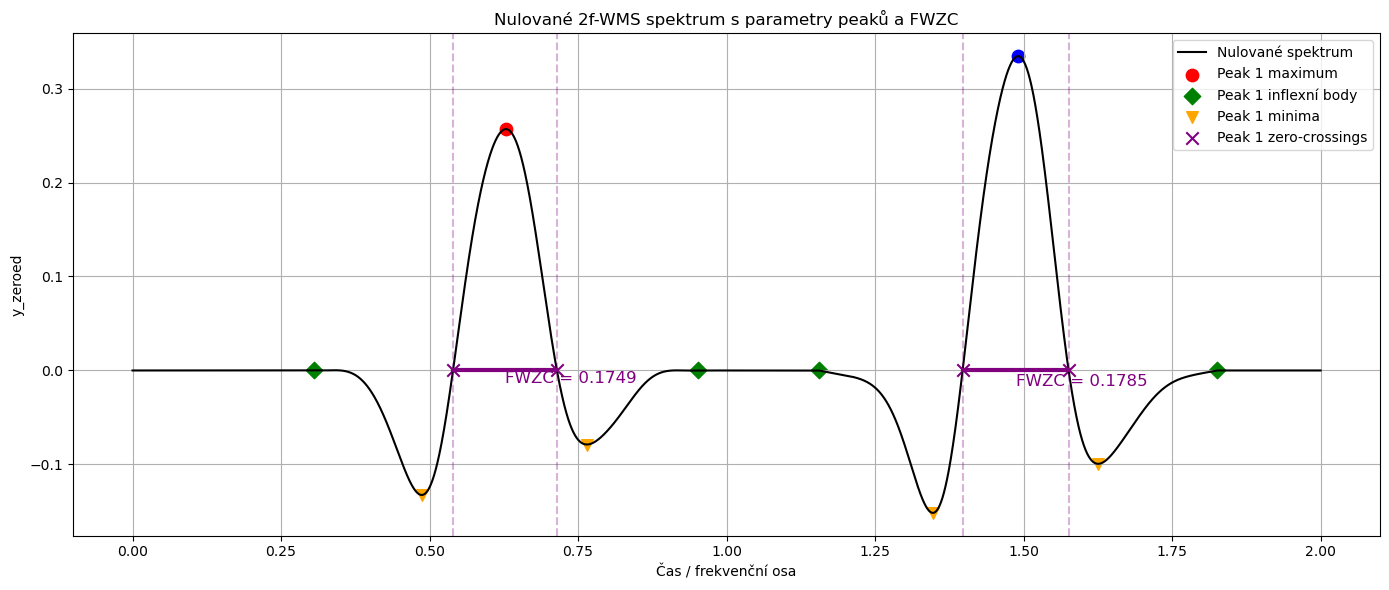

In [189]:
# ------------------------------------------------------------
# Vizualizace nulovaného spektra + parametry peaků + FWZC
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.plot(x, y_zeroed, label="Nulované spektrum", color="black")

colors = ["red", "blue"]  # Peak 1, Peak 2

for pid, row in enumerate(peak_data):
    peak_id = row[0]
    x_min_left, x_min_right = row[1], row[2]
    x_max = row[3]
    x_inf_left, x_inf_right = row[4], row[5]
    A2f_corr, H2f_corr = row[6], row[7]
    zc_left, zc_right = row[8], row[9]
    FWZC = row[10]

    col = colors[pid]

    # Maximum piku
    y_max = y_zeroed[np.argmin(np.abs(x - x_max))]
    plt.scatter([x_max], [y_max], color=col, s=80, marker="o",
                label=f"Peak {peak_id} maximum" if pid == 0 else None)

    # Inflexní body
    y_inf_left = y_zeroed[np.argmin(np.abs(x - x_inf_left))]
    y_inf_right = y_zeroed[np.argmin(np.abs(x - x_inf_right))]
    plt.scatter([x_inf_left, x_inf_right], [y_inf_left, y_inf_right],
                color="green", s=70, marker="D",
                label=f"Peak {peak_id} inflexní body" if pid == 0 else None)

    # Minima
    if not np.isnan(x_min_left):
        y_ml = y_zeroed[np.argmin(np.abs(x - x_min_left))]
        plt.scatter([x_min_left], [y_ml], color="orange", s=70, marker="v",
                    label=f"Peak {peak_id} minima" if pid == 0 else None)

    if not np.isnan(x_min_right):
        y_mr = y_zeroed[np.argmin(np.abs(x - x_min_right))]
        plt.scatter([x_min_right], [y_mr], color="orange", s=70, marker="v")

    # Zero-crossing body
    if not np.isnan(zc_left):
        plt.scatter([zc_left], [0], color="purple", s=80, marker="x",
                    label=f"Peak {peak_id} zero-crossings" if pid == 0 else None)
        plt.axvline(zc_left, color="purple", linestyle="--", alpha=0.3)

    if not np.isnan(zc_right):
        plt.scatter([zc_right], [0], color="purple", s=80, marker="x")
        plt.axvline(zc_right, color="purple", linestyle="--", alpha=0.3)

    # FWZC vizualizace
    if not np.isnan(FWZC):
        plt.plot([zc_left, zc_right], [0, 0], color="purple", linewidth=3)
        plt.text((zc_left + zc_right)/2, -0.05 * H2f_corr,
                 f"FWZC = {FWZC:.4f}", color="purple", fontsize=12)

plt.title("Nulované 2f-WMS spektrum s parametry peaků a FWZC")
plt.xlabel("Čas / frekvenční osa")
plt.ylabel("y_zeroed")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
